In [4]:
#어제 같이 올렸는데 파일 2개가 누락되서 지금 다시 올립니다....죄송합니다.

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D,
    LSTM,
    Dense, Dropout, Flatten
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
# --- 1. 데이터 로드 및 전처리 ---

# 데이터셋이 압축 해제된 경로 (본인 환경에 맞게 수정)
# 예: './data/UCI HAR Dataset/'
DATASET_PATH = '/content/drive/MyDrive/UCI HAR Dataset/'

# 원시 신호 데이터를 로드하는 함수
def load_signal_data(split): # split = 'train' 또는 'test'
    # 9개 축의 파일 리스트
    signal_files = [
        f'body_acc_x_{split}.txt', f'body_acc_y_{split}.txt', f'body_acc_z_{split}.txt',
        f'body_gyro_x_{split}.txt', f'body_gyro_y_{split}.txt', f'body_gyro_z_{split}.txt',
        f'total_acc_x_{split}.txt', f'total_acc_y_{split}.txt', f'total_acc_z_{split}.txt'
    ]

    # 데이터를 담을 리스트
    signal_data = []

    # 9개 파일을 순서대로 읽어서 리스트에 추가
    for file_name in signal_files:
        file_path = f'{DATASET_PATH}{split}/Inertial Signals/{file_name}'
        # 공백으로 구분된 텍스트 파일을 로드
        df = pd.read_csv(file_path, delim_whitespace=True, header=None)
        # NumPy 배열로 변환하여 리스트에 추가
        signal_data.append(df.values)

    # (9, 샘플 수, 128) 형태의 리스트를 (샘플 수, 128, 9) 형태로 변환
    # np.stack을 사용해 3번째 축(특징 축)으로 쌓음
    X_data = np.stack(signal_data, axis=-1)

    return X_data

# 라벨 데이터를 로드하는 함수
def load_label_data(split): # split = 'train' 또는 'test'
    file_path = f'{DATASET_PATH}{split}/y_{split}.txt'
    df = pd.read_csv(file_path, header=None)

    # 라벨이 1부터 6까지이므로 0부터 5까지로 조정 (원-핫 인코딩을 위해)
    y_data = df.values - 1

    # 원-핫 인코딩 수행
    return to_categorical(y_data, num_classes=6)

# 데이터 로드 실행
print("데이터 로딩 시작...")
X_train = load_signal_data('train')
X_test = load_signal_data('test')
y_train = load_label_data('train')
y_test = load_label_data('test')

데이터 로딩 시작...


/tmp/ipython-input-3956007466.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-3956007466.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-3956007466.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-3956007466.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-3

In [38]:
# 데이터 형태 가져오기
n_timesteps = X_train.shape[1] # 128
n_features = X_train.shape[2]  # 9
n_classes = y_train.shape[1]   # 6

In [39]:
# --- 2. CNN + LSTM 모델 구축 ---

print("\n--- CNN-LSTM 모델 구축 ---")

model = Sequential()

# === CNN 부분 (원본: 64 필터, 2개 레이어) ===
model.add(Conv1D(filters=64, kernel_size=3, activation='relu',
               input_shape=(n_timesteps, n_features)))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu')) # <--- 두 번째 레이어
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.5))


# === LSTM 부분 (원본: 100 유닛) ===
model.add(LSTM(100)) # <--- 100 유닛
model.add(Dropout(0.5))


# === 분류기 부분 (원본: 100 유닛) ===
model.add(Dense(100, activation='relu')) # <--- 100 유닛
model.add(Dense(n_classes, activation='softmax'))

model.summary()


--- CNN-LSTM 모델 구축 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_14 (Conv1D)              │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 124, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100)            │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,850 (354.88 KB)

 Trainable params: 90,850 (354.88 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# --- 3. 모델 컴파일 및 학습 ---
# (이 부분은 '개선된' 버전을 그대로 사용!)

print("\n--- 모델 컴파일 및 학습 시작 ---")

# 💡 핵심: 낮은 학습률(0.0001)은 그대로 유지
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

# 💡 핵심: 조기 종료(EarlyStopping)도 그대로 유지
early_stopping = EarlyStopping(monitor='val_loss',
                              patience=5,
                              restore_best_weights=True)

# 모델 학습
history = model.fit(X_train, y_train,
                    epochs=30, # (조기 종료될 수 있음)
                    batch_size=64,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping])


--- 모델 컴파일 및 학습 시작 ---
Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.2801 - loss: 1.7256 - val_accuracy: 0.5521 - val_loss: 1.1596
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6301 - loss: 0.9202 - val_accuracy: 0.7194 - val_loss: 0.7137
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7101 - loss: 0.6393 - val_accuracy: 0.7336 - val_loss: 0.6535
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7866 - loss: 0.5252 - val_accuracy: 0.7564 - val_loss: 0.6179
Epoch 5/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8426 - loss: 0.4242 - val_accuracy: 0.7570 - val_loss: 0.6532
Epoch 6/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8649 - loss: 0.3865 - val_accuracy: 0.7896 - val_loss: 0.6095
Epoch 7/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8911 - loss: 0.3253 - val_accuracy: 0.8415 - val_loss: 0.5111
Epoch 8/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9011 -

In [41]:
# --- 4. 모델 평가 ---
# (이전과 동일)
print("\n--- 모델 평가 ---")
loss, accuracy = model.evaluate(X_test, y_test)
print(f'테스트 데이터 손실(Loss): {loss:.4f}')
print(f'테스트 데이터 정확도(Accuracy): {accuracy * 100:.2f} %')


--- 모델 평가 ---
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8386 - loss: 0.4375
테스트 데이터 손실(Loss): 0.3678
테스트 데이터 정확도(Accuracy): 88.94 %



--- 학습 커브 그리기 ---


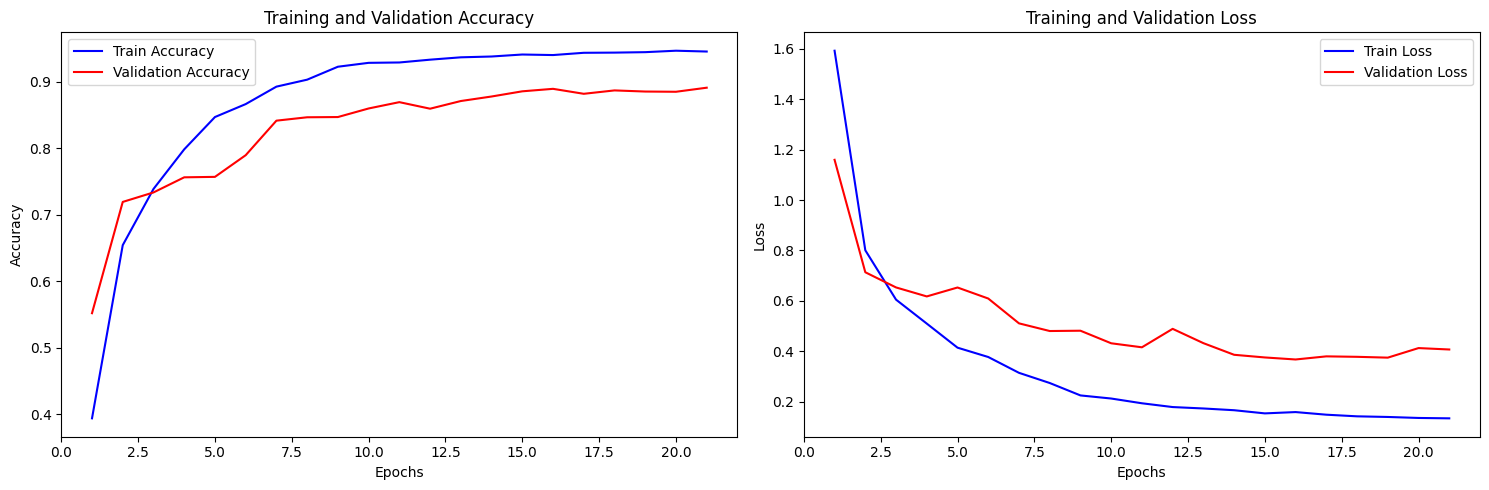

In [42]:

import matplotlib.pyplot as plt

# ----------------------------------------
# 1. 학습 커브 (정확도 및 손실)
# ----------------------------------------
print("\n--- 학습 커브 그리기 ---")

# history 객체에서 훈련 및 검증 정확도/손실 추출
history_dict = history.history
train_acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
train_loss = history_dict['loss']
val_loss = history_dict['val_loss']

# 에포크 수
epochs = range(1, len(train_acc) + 1)

# 1x2 크기의 서브플롯 생성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 📈 첫 번째 플롯: 정확도 (Accuracy)
ax1.plot(epochs, train_acc, 'b-', label='Train Accuracy')
ax1.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# 📉 두 번째 플롯: 손실 (Loss)
ax2.plot(epochs, train_loss, 'b-', label='Train Loss')
ax2.plot(epochs, val_loss, 'r-', label='Validation Loss')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()


--- 혼동 행렬 그리기 ---
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


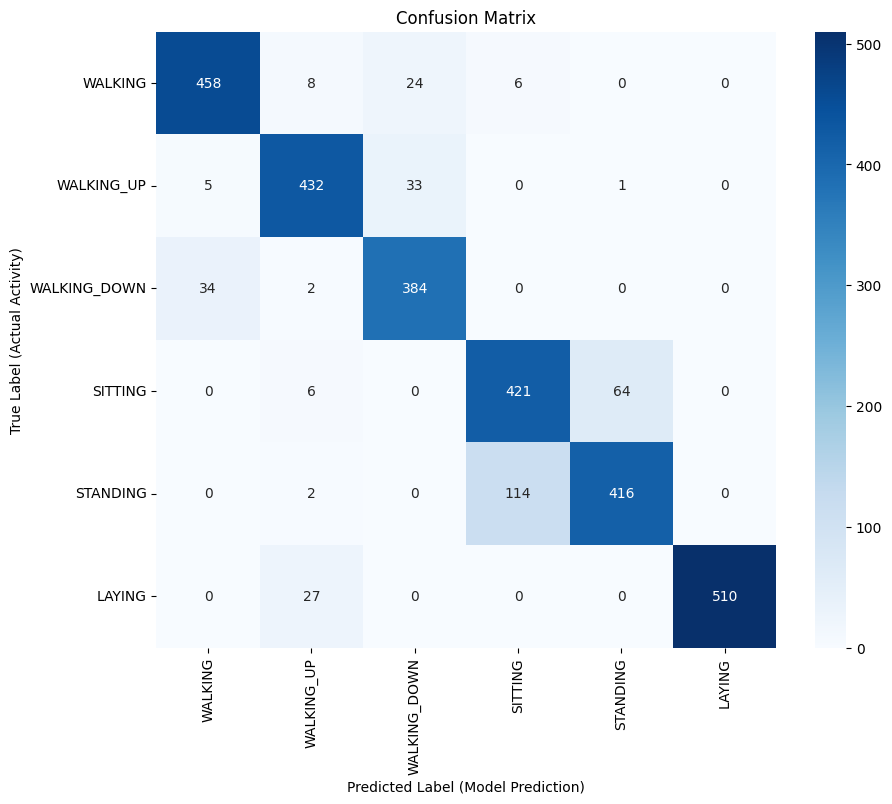

In [43]:
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# ----------------------------------------
# 2. 혼동 행렬 (Confusion Matrix)
# ----------------------------------------
print("\n--- 혼동 행렬 그리기 ---")

# 테스트 데이터(X_test)로 예측 수행
y_pred_probs = model.predict(X_test)

# 확률을 클래스 인덱스로 변환
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 실제 라벨(y_test)도 클래스 인덱스로 변환
y_true = np.argmax(y_test, axis=1)

# 혼동 행렬 계산
cm = confusion_matrix(y_true, y_pred_classes)

# 클래스(동작) 이름
class_names = [
    'WALKING', 'WALKING_UP', 'WALKING_DOWN',
    'SITTING', 'STANDING', 'LAYING'
]

# Seaborn으로 혼동 행렬 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.ylabel('True Label (Actual Activity)')
plt.xlabel('Predicted Label (Model Prediction)')
plt.show()